<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <img src="../assets/branding/logoUgrupo.png" alt="Universidad del Magdalena y GIDSYC" style="height: 76px; max-width: 34%; object-fit: contain;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Modelos de difusión para IA generativa</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 08</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Classifier-free guidance</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Semillero GIDSYC | Facultad de Ingenierías | Programa de Ingeniería de Sistemas</div>
    </div>
    <img src="../assets/branding/logo_semillero.png" alt="Semillero GIDSYC" style="height: 74px; object-fit: contain;">
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
  <div><strong>Grupo:</strong> GIDSYC</div>
  <div><strong>Unidad:</strong> Semillero GIDSYC</div>
  <div><strong>Universidad:</strong> Universidad del Magdalena</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>

## Pregunta directriz

> ¿Cómo controlar la intensidad de una condición sin entrenar un clasificador externo?

El notebook 07 introdujo generación condicional con etiquetas discretas. Allí el usuario fija una clase $y$ y el modelo genera una muestra compatible con esa clase. Esa formulación es suficiente para pasar de una distribución marginal $p(x)$ a distribuciones condicionales $p(x\mid y)$, pero todavía no ofrece un parámetro explícito para regular la fuerza con la que la condición interviene durante el muestreo.

Classifier-free guidance resuelve ese punto con una idea precisa: entrenar una misma red para operar en dos modos, con condición presente y con condición ausente. Durante el muestreo, evaluamos la red en ambos modos y combinamos sus predicciones. La diferencia entre las dos predicciones define una dirección semántica asociada a la condición.

## Objetivos

Al finalizar este notebook, el estudiante debería estar en capacidad de:

1. Formular el entrenamiento con eliminación aleatoria de la condición.
2. Interpretar la condición nula $\varnothing$ como un modo no condicional aprendido por la misma red.
3. Implementar classifier-free guidance en un DDPM de predicción de ruido.
4. Comparar muestreo no condicional, condicional simple y guiado.
5. Analizar el efecto del peso de guidance sobre fidelidad semántica y diversidad visual.
6. Reconocer que guidance modifica el procedimiento de muestreo, no el proceso directo de difusión.

## Marco conceptual

En el modelo condicional simple entrenamos $\epsilon_\theta(x_t,t,y)$ y usamos siempre una etiqueta durante el muestreo. Classifier-free guidance exige un cambio en el entrenamiento: en una fracción de los mini-lotes se reemplaza la etiqueta real por una condición nula. La red aprende entonces dos comportamientos relacionados: predecir ruido con información semántica y predecir ruido sin esa información.

La condición nula no es una clase adicional del dataset. Es un símbolo técnico que representa ausencia de condición. Su utilidad aparece al muestrear: para el mismo $x_t$ y el mismo $t$, calculamos una predicción condicional y una predicción no condicional. Si ambas predicciones son iguales, la condición no está aportando información. Si difieren, la resta entre ellas indica cómo la etiqueta modifica el denoising.

El parámetro de guidance amplifica esa diferencia. Por eso no hablamos simplemente de escoger una clase, sino de regular cuánto se fuerza la cadena inversa hacia la estructura asociada a esa clase.

## Formulación matemática

Sea un dataset etiquetado

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{N},
\qquad
y_i\in\{1,\dots,K\}.
$$

Extendemos el espacio de condiciones con un símbolo nulo:

$$
\mathcal{C}=\{1,\dots,K,\varnothing\}.
$$

Durante entrenamiento, la condición que recibe la red no siempre es la etiqueta real. Para una probabilidad de eliminación $p_{\mathrm{drop}}$, definimos

$$
c =
\begin{cases}
y, & \text{con probabilidad }1-p_{\mathrm{drop}},\\
\varnothing, & \text{con probabilidad }p_{\mathrm{drop}}.
\end{cases}
$$

El proceso directo sigue siendo

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon,
\qquad
\epsilon\sim\mathcal{N}(0,I),
$$

y el objetivo de entrenamiento queda

$$
\mathcal{L}_{\mathrm{cfg}}(\theta)
=
\mathbb{E}
\left[
\left\|
\epsilon
-
\epsilon_\theta(x_t,t,c)
\right\|_2^2
\right].
$$

En muestreo, para una etiqueta solicitada $y$, evaluamos la misma red dos veces:

$$
\epsilon_{\mathrm{cond}}
=
\epsilon_\theta(x_t,t,y),
\qquad
\epsilon_{\mathrm{null}}
=
\epsilon_\theta(x_t,t,\varnothing).
$$

La predicción guiada será

$$
\epsilon_{\mathrm{cfg}}
=
\epsilon_{\mathrm{cond}}
+
w\left(
\epsilon_{\mathrm{cond}}
-
\epsilon_{\mathrm{null}}
\right),
\qquad
w\geq 0.
$$

En esta convención, $w=0$ recupera el muestreo condicional ordinario. Valores mayores extrapolan en la dirección que separa la predicción condicional de la predicción no condicional.

<div style="margin: 18px 0 10px 0; text-align: center;">
  <img src="../assets/figures/formulacion_classifier_free_guidance.png" alt="Formulación de classifier-free guidance" style="max-width: 100%; border: 1px solid #d0d7de; border-radius: 6px;" />
</div>

<div style="text-align: center; color: #4a5568; font-size: 0.95em; margin-bottom: 6px;">
  Classifier-free guidance entrena una sola red con condición presente y ausente; la diferencia entre ambas predicciones se amplifica durante el muestreo.
</div>

## Preparación del entorno

Este notebook reutiliza QuickDraw multicategoría. El entrenamiento sigue siendo moderado: una U-Net pequeña, imágenes de $28\times 28$, cinco clases y checkpoint automático. La primera ejecución entrena el modelo; las siguientes cargan el archivo guardado.

In [1]:
import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

CWD = Path.cwd()
if CWD.name == "notebooks":
    ROOT = CWD.parent
elif (CWD / "src" / "difusion").exists():
    ROOT = CWD
else:
    ROOT = CWD / "courses" / "modelos_difusion_ia_generativa"

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from difusion.data.quickdraw import load_quickdraw_npz

DATASET_PATH = ROOT / "data" / "quickdraw" / "processed" / "quickdraw_5class_10k_each_28x28.npz"
CHECKPOINT_DIR = ROOT / "models"
CHECKPOINT_PATH = CHECKPOINT_DIR / "quickdraw_5class_cfg_tiny_unet.pt"

SEED = 20260425
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["image.cmap"] = "gray_r"

print("PyTorch:", torch.__version__)
print("Dispositivo:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(DEVICE))
else:
    print("Advertencia: no se detectó GPU. El entrenamiento completo tardará bastante más.")
print("Checkpoint:", CHECKPOINT_PATH.relative_to(ROOT))

PyTorch: 2.8.0+cu126
Dispositivo: cuda:0
GPU: NVIDIA RTX A6000
Checkpoint: models/quickdraw_5class_cfg_tiny_unet.pt


## Criterio experimental

El experimento no busca demostrar que guidance siempre mejora una muestra individual. Busca aislar el mecanismo: mantener la misma arquitectura y el mismo dataset del notebook 07, introducir condición nula durante entrenamiento y comparar el muestreo al variar $w$.

La lectura esperada es cualitativa. Un peso pequeño debería parecerse al modelo condicional simple. Un peso intermedio puede reforzar rasgos de la clase. Un peso excesivo puede producir trazos más rígidos, menos diversos o artefactos. Ese compromiso es parte esencial de classifier-free guidance.

## Dataset y condición nula

Usamos las mismas cinco categorías de QuickDraw. La condición nula se implementa como un índice adicional en la tabla de embeddings. Si las clases reales usan los índices $0,\dots,K-1$, el índice $K$ se reserva para $\varnothing$.

In [2]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró {DATASET_PATH}. "
        "Genere el dataset multicategoría antes de ejecutar este notebook."
    )

split = load_quickdraw_npz(DATASET_PATH, split="train")
x_all = split.normalized_images
y_all = split.labels.astype(np.int64)
class_names = np.array(split.class_names)
NUM_CLASSES = len(class_names)
NULL_LABEL = NUM_CLASSES
NUM_CONDITION_TOKENS = NUM_CLASSES + 1

MAX_PER_CLASS = 6_000
BATCH_SIZE = 256
COND_DROP_PROB = 0.15

rng = np.random.default_rng(SEED)
selected = []
for k in range(NUM_CLASSES):
    idx = np.flatnonzero(y_all == k)
    selected.append(rng.choice(idx, size=min(MAX_PER_CLASS, len(idx)), replace=False))
selected = np.concatenate(selected)
rng.shuffle(selected)

x_train = x_all[selected]
y_train = y_all[selected]

x_tensor = torch.from_numpy(x_train[:, None, :, :]).float()
y_tensor = torch.from_numpy(y_train).long()
loader = DataLoader(
    TensorDataset(x_tensor, y_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=0,
)

counts = np.bincount(y_train, minlength=NUM_CLASSES)
print("Clases:", class_names.tolist())
print("Índice de condición nula:", NULL_LABEL)
print("Probabilidad de eliminar condición:", COND_DROP_PROB)
print("Muestras usadas:", len(x_train))
for name, count in zip(class_names, counts):
    print(f"{name:>6s}: {count:5d}")

Clases: ['house', 'cat', 'tree', 'fish', 'apple']
Índice de condición nula: 5
Probabilidad de eliminar condición: 0.15
Muestras usadas: 30000
 house:  6000
   cat:  6000
  tree:  6000
  fish:  6000
 apple:  6000


In [3]:
def apply_condition_dropout(labels, drop_prob=COND_DROP_PROB):
    dropped = labels.clone()
    mask = torch.rand(labels.shape[0], device=labels.device) < drop_prob
    dropped[mask] = NULL_LABEL
    return dropped, mask


example_labels = torch.tensor([0, 1, 2, 3, 4, 0, 1, 2, 3, 4], device=DEVICE)
example_dropped, example_mask = apply_condition_dropout(example_labels, drop_prob=0.35)

readable = []
for original, used in zip(example_labels.cpu().numpy(), example_dropped.cpu().numpy()):
    original_name = class_names[original]
    used_name = "∅" if used == NULL_LABEL else class_names[used]
    readable.append(f"{original_name}→{used_name}")
print("Ejemplo de condición usada por la red:")
print(", ".join(readable))

Ejemplo de condición usada por la red:
house→∅, cat→cat, tree→∅, fish→fish, apple→∅, house→house, cat→cat, tree→∅, fish→∅, apple→∅


## Agenda de ruido

La agenda de ruido se mantiene igual que en los notebooks anteriores. Classifier-free guidance no modifica la difusión directa; modifica la forma en que se entrena y se usa la red de denoising.

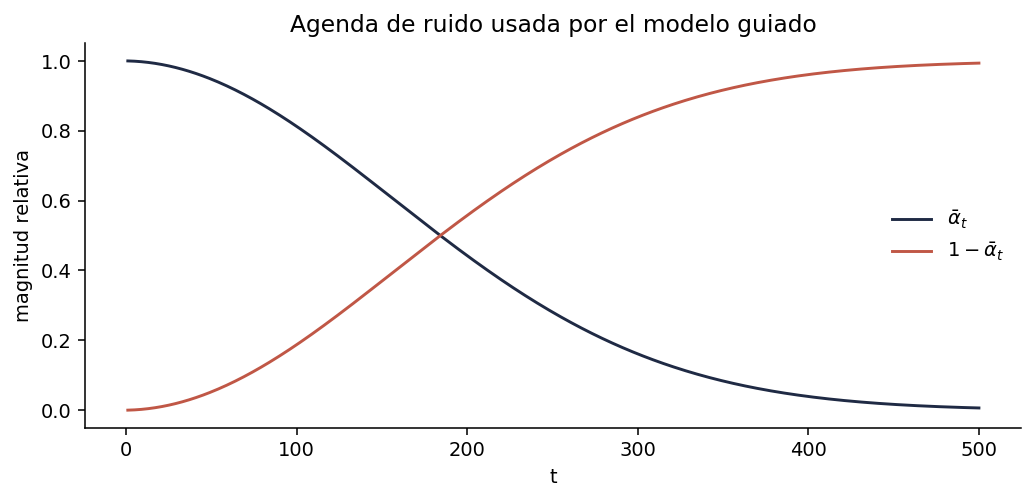

In [4]:
T = 500
beta_inicio = 1e-4
beta_fin = 2e-2

betas = torch.linspace(beta_inicio, beta_fin, T, dtype=torch.float32, device=DEVICE)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)


def q_sample(x0, t_index, eps=None):
    if eps is None:
        eps = torch.randn_like(x0)
    alpha_bar_t = alpha_bars[t_index].view(-1, 1, 1, 1)
    xt = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1.0 - alpha_bar_t) * eps
    return xt, eps


fig, ax = plt.subplots(figsize=(7.5, 3.7))
ax.plot(torch.arange(1, T + 1).cpu(), alpha_bars.cpu(), color="#1f2a44", label=r"$\bar{\alpha}_t$")
ax.plot(torch.arange(1, T + 1).cpu(), (1.0 - alpha_bars).cpu(), color="#c05746", label=r"$1-\bar{\alpha}_t$")
ax.set_xlabel("t")
ax.set_ylabel("magnitud relativa")
ax.set_title("Agenda de ruido usada por el modelo guiado")
ax.legend(frameon=False)
fig.tight_layout()

## Arquitectura con condición nula

La arquitectura es la misma U-Net mínima del notebook 07, con una sola diferencia estructural: la tabla de embeddings tiene $K+1$ entradas. Las primeras $K$ corresponden a clases reales y la entrada adicional corresponde a $\varnothing$.

Esto es importante: no entrenamos dos redes. Una única red comparte parámetros para el modo condicional y el modo no condicional. Esa compartición hace posible comparar predicciones bajo la misma geometría aprendida.

In [5]:
def sinusoidal_time_embedding(t_index, dim=96):
    half = dim // 2
    t = t_index.float() / max(T - 1, 1)
    freqs = torch.exp(
        -math.log(10000.0) * torch.arange(half, device=t_index.device) / max(half - 1, 1)
    )
    args = t[:, None] * freqs[None, :]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=1)


class ConditionedBlock(nn.Module):
    def __init__(self, in_channels, out_channels, cond_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.cond_proj = nn.Linear(cond_dim, out_channels)
        self.skip = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels
            else nn.Identity()
        )
        self.act = nn.SiLU()

    def forward(self, x, cond):
        bias = self.cond_proj(cond)[:, :, None, None]
        h = self.act(self.conv1(x) + bias)
        h = self.conv2(h)
        return self.act(h + self.skip(x))


class TinyCFGUNet(nn.Module):
    def __init__(self, num_condition_tokens, cond_dim=96, base=64):
        super().__init__()
        self.cond_dim = cond_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(cond_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )
        self.condition_embedding = nn.Embedding(num_condition_tokens, cond_dim)
        self.condition_mlp = nn.Sequential(
            nn.Linear(cond_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )
        self.input_block = ConditionedBlock(1, base, cond_dim)
        self.down1 = nn.Conv2d(base, 2 * base, kernel_size=4, stride=2, padding=1)
        self.encoder_block = ConditionedBlock(2 * base, 2 * base, cond_dim)
        self.down2 = nn.Conv2d(2 * base, 2 * base, kernel_size=4, stride=2, padding=1)
        self.middle_block = ConditionedBlock(2 * base, 2 * base, cond_dim)
        self.up1 = nn.ConvTranspose2d(2 * base, 2 * base, kernel_size=4, stride=2, padding=1)
        self.decoder_block = ConditionedBlock(4 * base, base, cond_dim)
        self.up2 = nn.ConvTranspose2d(base, base, kernel_size=4, stride=2, padding=1)
        self.output_block = ConditionedBlock(2 * base, base, cond_dim)
        self.output_conv = nn.Conv2d(base, 1, kernel_size=3, padding=1)

    def condition(self, t_index, labels):
        t_emb = sinusoidal_time_embedding(t_index, dim=self.cond_dim)
        t_emb = self.time_mlp(t_emb)
        c_emb = self.condition_mlp(self.condition_embedding(labels))
        return t_emb + c_emb

    def forward(self, x, t_index, labels):
        cond = self.condition(t_index, labels)
        skip_28 = self.input_block(x, cond)
        h_14 = self.encoder_block(self.down1(skip_28), cond)
        h_7 = self.middle_block(self.down2(h_14), cond)
        h = self.up1(h_7)
        h = self.decoder_block(torch.cat([h, h_14], dim=1), cond)
        h = self.up2(h)
        h = self.output_block(torch.cat([h, skip_28], dim=1), cond)
        return self.output_conv(h)


model = TinyCFGUNet(num_condition_tokens=NUM_CONDITION_TOKENS, cond_dim=96, base=64).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros entrenables: {n_params:,}")
print(f"Tokens de condición: {NUM_CONDITION_TOKENS} = {NUM_CLASSES} clases + condición nula")

Parámetros entrenables: 1,751,105
Tokens de condición: 6 = 5 clases + condición nula


## Entrenamiento con eliminación de condición

En cada mini-lote se muestrea $t$, se construye $x_t$ y se decide aleatoriamente si cada etiqueta se conserva o se reemplaza por $\varnothing$. La pérdida sigue siendo MSE de predicción de ruido. Lo que cambia es la distribución de condiciones que observa la red durante entrenamiento.

In [6]:
LEARNING_RATE = 2e-4
EPOCHS = 40


def train_model(model, loader):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    loss_history = []
    epoch_history = []
    drop_history = []
    start_time = time.perf_counter()

    model.train()
    for epoch in range(1, EPOCHS + 1):
        epoch_losses = []
        epoch_drop_rates = []
        for x0, labels in loader:
            x0 = x0.to(DEVICE)
            labels = labels.to(DEVICE)
            b = x0.shape[0]
            t_index = torch.randint(0, T, (b,), device=DEVICE)
            eps = torch.randn_like(x0)
            xt, eps = q_sample(x0, t_index, eps)

            train_labels, drop_mask = apply_condition_dropout(labels)
            eps_pred = model(xt, t_index, train_labels)
            loss = torch.mean((eps - eps_pred) ** 2)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            value = float(loss.detach().cpu())
            loss_history.append(value)
            epoch_losses.append(value)
            epoch_drop_rates.append(float(drop_mask.float().mean().detach().cpu()))

        epoch_mean = float(np.mean(epoch_losses))
        drop_mean = float(np.mean(epoch_drop_rates))
        epoch_history.append(epoch_mean)
        drop_history.append(drop_mean)
        print(
            f"época {epoch:02d}/{EPOCHS} | "
            f"loss promedio={epoch_mean:.4f} | "
            f"drop={drop_mean:.3f}"
        )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start_time
    print(f"Tiempo total de entrenamiento: {elapsed:.2f} s")
    return loss_history, epoch_history, drop_history, elapsed


CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

if CHECKPOINT_PATH.exists():
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    loss_history = checkpoint.get("loss_history", [])
    epoch_history = checkpoint.get("epoch_history", [])
    drop_history = checkpoint.get("drop_history", [])
    training_time = checkpoint.get("training_time_seconds", None)
    print("Checkpoint cargado.")
    if epoch_history:
        print(f"Épocas almacenadas: {len(epoch_history)} | última pérdida promedio: {epoch_history[-1]:.4f}")
else:
    loss_history, epoch_history, drop_history, training_time = train_model(model, loader)
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "loss_history": loss_history,
        "epoch_history": epoch_history,
        "drop_history": drop_history,
        "training_time_seconds": training_time,
        "class_names": class_names.tolist(),
        "null_label": NULL_LABEL,
        "config": {
            "T": T,
            "beta_inicio": beta_inicio,
            "beta_fin": beta_fin,
            "num_classes": NUM_CLASSES,
            "num_condition_tokens": NUM_CONDITION_TOKENS,
            "null_label": NULL_LABEL,
            "max_per_class": MAX_PER_CLASS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "epochs": EPOCHS,
            "cond_drop_prob": COND_DROP_PROB,
            "cond_dim": 96,
            "base": 64,
        },
    }
    torch.save(checkpoint, CHECKPOINT_PATH)
    print("Checkpoint guardado en:", CHECKPOINT_PATH.relative_to(ROOT))

Checkpoint cargado.
Épocas almacenadas: 40 | última pérdida promedio: 0.0581


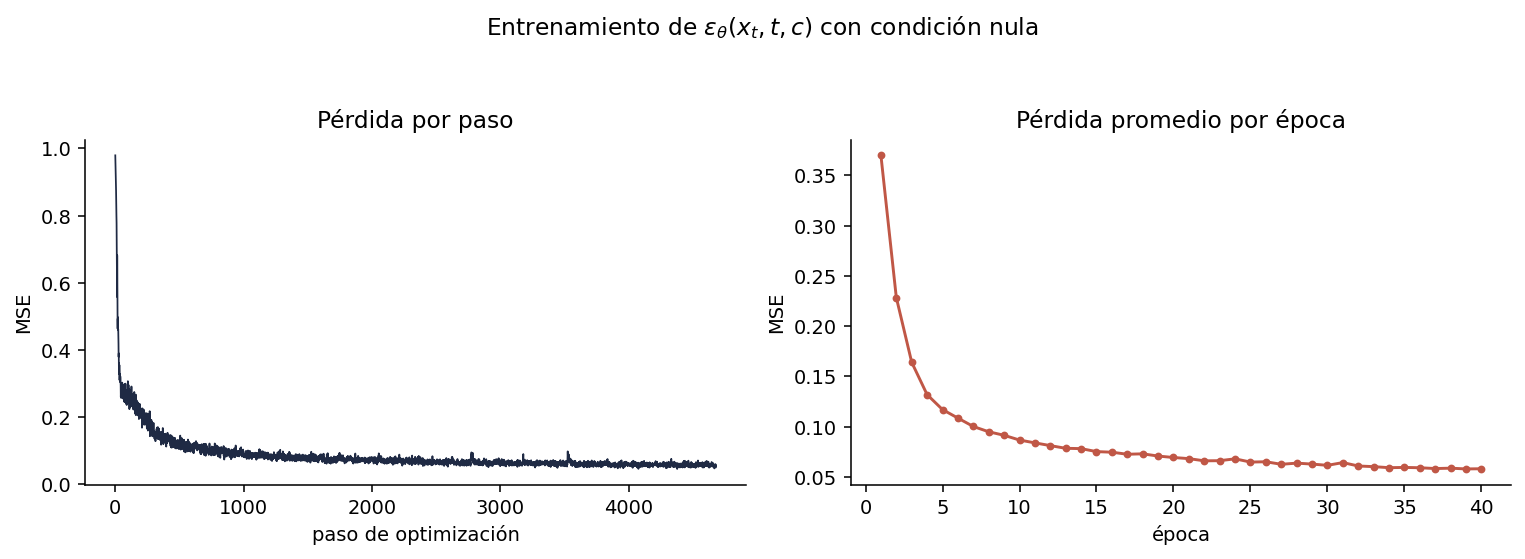

In [7]:
if loss_history:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    axes[0].plot(loss_history, color="#1f2a44", linewidth=0.9)
    axes[0].set_title("Pérdida por paso")
    axes[0].set_xlabel("paso de optimización")
    axes[0].set_ylabel("MSE")
    axes[1].plot(range(1, len(epoch_history) + 1), epoch_history, color="#c05746", marker="o", markersize=3)
    axes[1].set_title("Pérdida promedio por época")
    axes[1].set_xlabel("época")
    axes[1].set_ylabel("MSE")
    fig.suptitle(r"Entrenamiento de $\epsilon_\theta(x_t,t,c)$ con condición nula", y=1.04)
    fig.tight_layout()
else:
    print("No hay historial de pérdida disponible en el checkpoint.")

## Comparación de predicciones

Para un mismo $x_t$ y un mismo tiempo, la red puede evaluarse con una etiqueta real o con $\varnothing$. La diferencia entre esas predicciones es la señal que classifier-free guidance amplifica. No es una nueva red ni un clasificador auxiliar; es una comparación interna de dos modos de la misma red.

 house | ||eps_cond - eps_null|| promedio: 0.0665
   cat | ||eps_cond - eps_null|| promedio: 0.0202
  tree | ||eps_cond - eps_null|| promedio: 0.0479
  fish | ||eps_cond - eps_null|| promedio: 0.0464
 apple | ||eps_cond - eps_null|| promedio: 0.0452


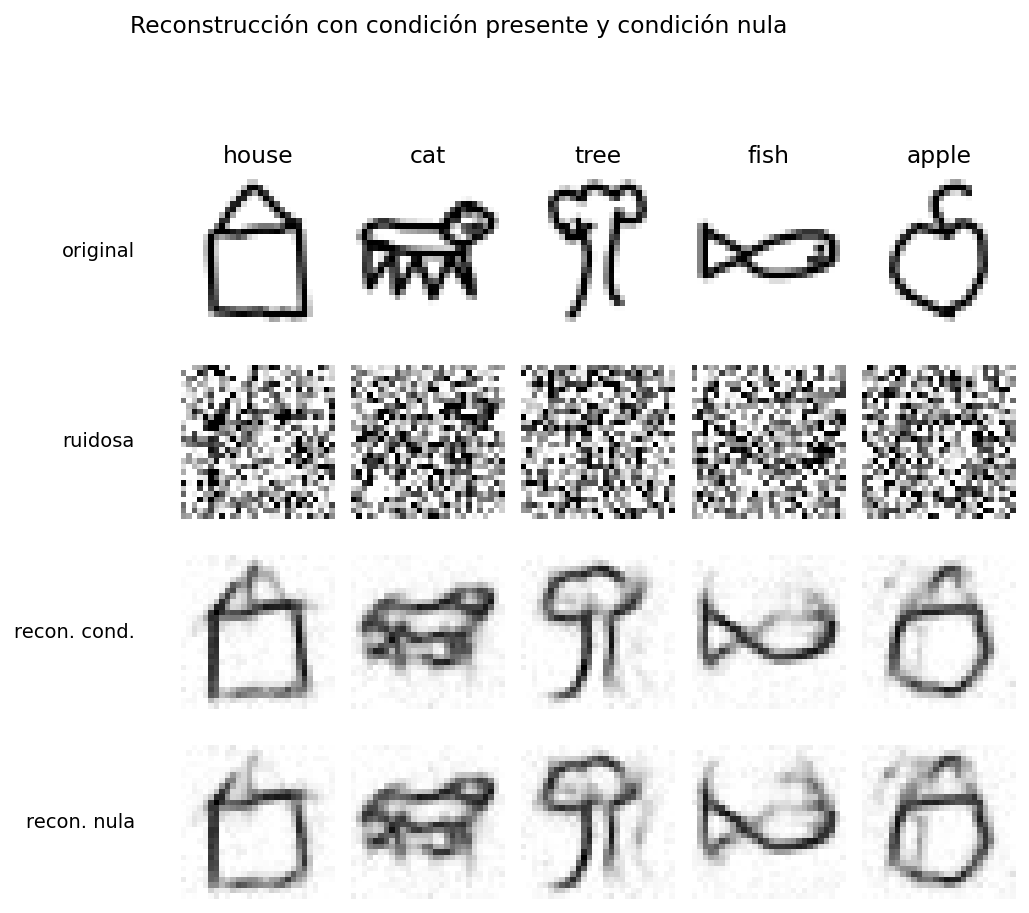

In [8]:
def to_image_range(x):
    return torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)


def reconstruct_x0_from_epsilon(xt, eps_pred, t_index):
    alpha_bar_t = alpha_bars[t_index].view(-1, 1, 1, 1)
    return (xt - torch.sqrt(1.0 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)


model.eval()
chosen_indices = []
for k in range(NUM_CLASSES):
    idx = np.flatnonzero(y_train == k)
    chosen_indices.append(rng.choice(idx))

x0 = x_tensor[chosen_indices].to(DEVICE)
labels = y_tensor[chosen_indices].to(DEVICE)
null_labels = torch.full_like(labels, NULL_LABEL)
t_index = torch.full((NUM_CLASSES,), int(0.55 * T), device=DEVICE, dtype=torch.long)
eps = torch.randn_like(x0)
xt, eps = q_sample(x0, t_index, eps)

with torch.no_grad():
    eps_cond = model(xt, t_index, labels)
    eps_null = model(xt, t_index, null_labels)
    x0_cond = reconstruct_x0_from_epsilon(xt, eps_cond, t_index)
    x0_null = reconstruct_x0_from_epsilon(xt, eps_null, t_index)
    difference_norm = torch.mean((eps_cond - eps_null) ** 2, dim=(1, 2, 3)).sqrt().detach().cpu().numpy()

fig, axes = plt.subplots(4, NUM_CLASSES, figsize=(NUM_CLASSES * 1.65, 6.4))
rows = [
    ("original", x0),
    ("ruidosa", xt),
    ("recon. cond.", x0_cond),
    ("recon. nula", x0_null),
]
for row, (row_name, tensor) in enumerate(rows):
    for col in range(NUM_CLASSES):
        axes[row, col].imshow(to_image_range(tensor[col, 0]).detach().cpu(), vmin=0, vmax=1)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(str(class_names[col]))
        if col == 0:
            axes[row, col].text(-0.30, 0.5, row_name, transform=axes[row, col].transAxes, ha="right", va="center")
fig.suptitle("Reconstrucción con condición presente y condición nula", y=1.02)
fig.tight_layout(rect=[0.10, 0.0, 1.0, 0.96])

for name, value in zip(class_names, difference_norm):
    print(f"{name:>6s} | ||eps_cond - eps_null|| promedio: {value:.4f}")

La comparación anterior debe leerse con cuidado. En una reconstrucción de una imagen real, especialmente cuando todavía queda señal visible en $x_t$, las predicciones condicional y nula pueden producir resultados visualmente parecidos. Eso no significa que la condición sea irrelevante. En classifier-free guidance, la diferencia entre ambas predicciones se aplica repetidamente a lo largo de toda la cadena inversa. Un desplazamiento pequeño por paso puede convertirse en una modificación visible de la muestra final.

## Muestreo guiado

En el paso inverso reemplazamos la predicción de ruido ordinaria por $\epsilon_{\mathrm{cfg}}$. El resto del muestreo DDPM permanece igual. El parámetro $w$ solo interviene en la estimación del ruido que define la media del paso inverso.

In [9]:
@torch.no_grad()
def predict_epsilon_cfg(model, x, t_batch, labels, guidance_weight=0.0):
    eps_cond = model(x, t_batch, labels)
    if guidance_weight == 0:
        return eps_cond
    null_labels = torch.full_like(labels, NULL_LABEL)
    eps_null = model(x, t_batch, null_labels)
    return eps_cond + guidance_weight * (eps_cond - eps_null)


@torch.no_grad()
def sample_ddpm_cfg(model, labels, guidance_weight=0.0, initial_noise=None, save_steps=None):
    model.eval()
    labels = labels.to(DEVICE)
    n = labels.shape[0]
    if initial_noise is None:
        x = torch.randn(n, 1, 28, 28, device=DEVICE)
    else:
        x = initial_noise.to(DEVICE).clone()

    snapshots = {}
    save_steps = set(save_steps or [])

    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, device=DEVICE, dtype=torch.long)
        eps_pred = predict_epsilon_cfg(model, x, t_batch, labels, guidance_weight=guidance_weight)

        beta_t = betas[t].view(1, 1, 1, 1)
        alpha_t = alphas[t].view(1, 1, 1, 1)
        alpha_bar_t = alpha_bars[t].view(1, 1, 1, 1)
        if t > 0:
            alpha_bar_prev = alpha_bars[t - 1].view(1, 1, 1, 1)
            posterior_var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t)
            z = torch.randn_like(x)
        else:
            posterior_var = torch.zeros_like(beta_t)
            z = torch.zeros_like(x)

        mean = (1.0 / torch.sqrt(alpha_t)) * (
            x - beta_t / torch.sqrt(1.0 - alpha_bar_t) * eps_pred
        )
        x = mean + torch.sqrt(posterior_var) * z

        if t in save_steps:
            snapshots[t] = x.detach().cpu()

    snapshots[0] = x.detach().cpu()
    return x.detach().cpu(), snapshots


@torch.no_grad()
def sample_ddpm_unconditional(model, n, initial_noise=None):
    labels = torch.full((n,), NULL_LABEL, device=DEVICE, dtype=torch.long)
    x = torch.randn(n, 1, 28, 28, device=DEVICE) if initial_noise is None else initial_noise.to(DEVICE).clone()

    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, device=DEVICE, dtype=torch.long)
        eps_pred = model(x, t_batch, labels)

        beta_t = betas[t].view(1, 1, 1, 1)
        alpha_t = alphas[t].view(1, 1, 1, 1)
        alpha_bar_t = alpha_bars[t].view(1, 1, 1, 1)
        if t > 0:
            alpha_bar_prev = alpha_bars[t - 1].view(1, 1, 1, 1)
            posterior_var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t)
            z = torch.randn_like(x)
        else:
            posterior_var = torch.zeros_like(beta_t)
            z = torch.zeros_like(x)

        mean = (1.0 / torch.sqrt(alpha_t)) * (
            x - beta_t / torch.sqrt(1.0 - alpha_bar_t) * eps_pred
        )
        x = mean + torch.sqrt(posterior_var) * z

    return x.detach().cpu()

## Muestras no condicionales

Como la red aprendió también el símbolo $\varnothing$, podemos generar sin especificar clase. Estas muestras representan el modo marginal aprendido por la red dentro del mismo modelo que usaremos para guidance.

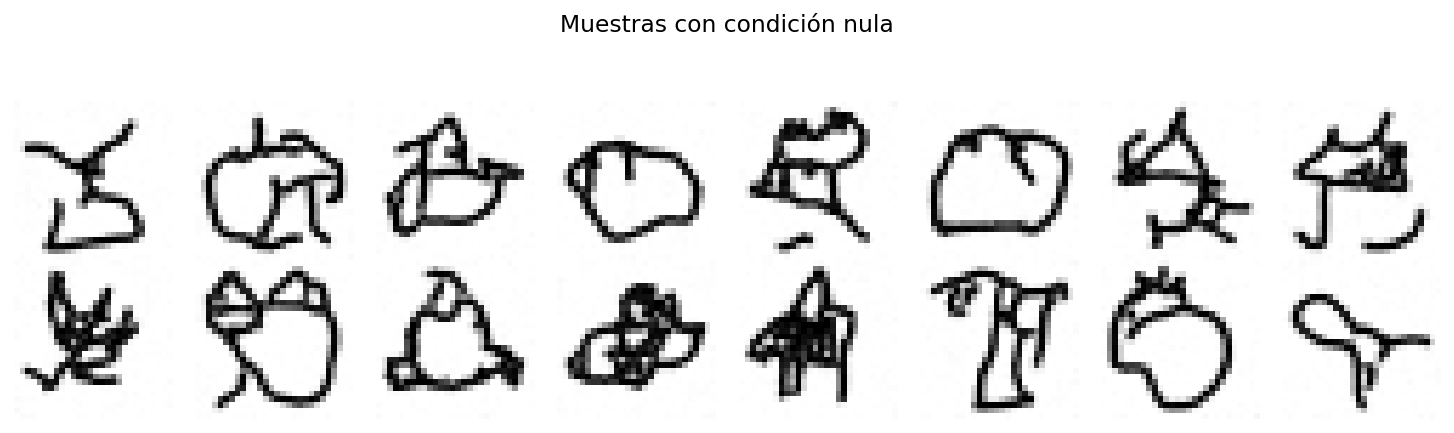

In [10]:
uncond_samples = sample_ddpm_unconditional(model, n=16)

fig, axes = plt.subplots(2, 8, figsize=(10.5, 2.9))
for ax, image in zip(axes.ravel(), uncond_samples):
    ax.imshow(to_image_range(image[0]), vmin=0, vmax=1)
    ax.axis("off")
fig.suptitle("Muestras con condición nula", y=1.05)
fig.tight_layout()

## Efecto del peso de guidance

Para observar el efecto de $w$, fijamos el mismo ruido inicial por clase y cambiamos únicamente el peso de guidance. Cada fila corresponde a una clase; cada columna usa una intensidad distinta. Así se evita confundir el efecto de $w$ con la variabilidad de la semilla.

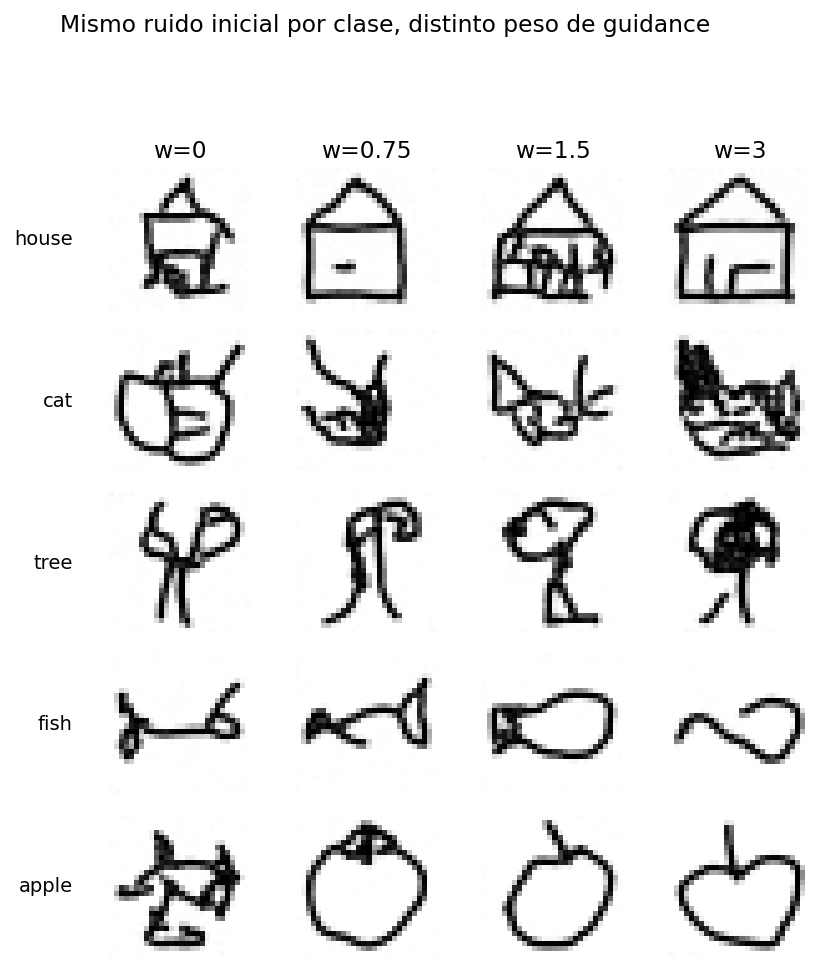

In [11]:
guidance_weights = [0.0, 0.75, 1.5, 3.0]
labels = torch.arange(NUM_CLASSES, device=DEVICE)
base_noise = torch.randn(NUM_CLASSES, 1, 28, 28, device=DEVICE)

guided_by_weight = []
for w in guidance_weights:
    samples, _ = sample_ddpm_cfg(model, labels, guidance_weight=w, initial_noise=base_noise, save_steps=[0])
    guided_by_weight.append(samples)

fig, axes = plt.subplots(NUM_CLASSES, len(guidance_weights), figsize=(len(guidance_weights) * 1.7, NUM_CLASSES * 1.35))
for row, name in enumerate(class_names):
    for col, w in enumerate(guidance_weights):
        axes[row, col].imshow(to_image_range(guided_by_weight[col][row, 0]), vmin=0, vmax=1)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"w={w:g}")
        if col == 0:
            axes[row, col].text(-0.26, 0.5, str(name), transform=axes[row, col].transAxes, ha="right", va="center", fontsize=10)
fig.suptitle("Mismo ruido inicial por clase, distinto peso de guidance", y=1.02)
fig.tight_layout(rect=[0.08, 0.0, 1.0, 0.96])

## Variabilidad bajo una misma clase

Guidance no elimina el carácter generativo del modelo. Para una clase fija, distintas semillas iniciales producen variantes. La condición orienta la cadena inversa, pero no determina una única imagen.

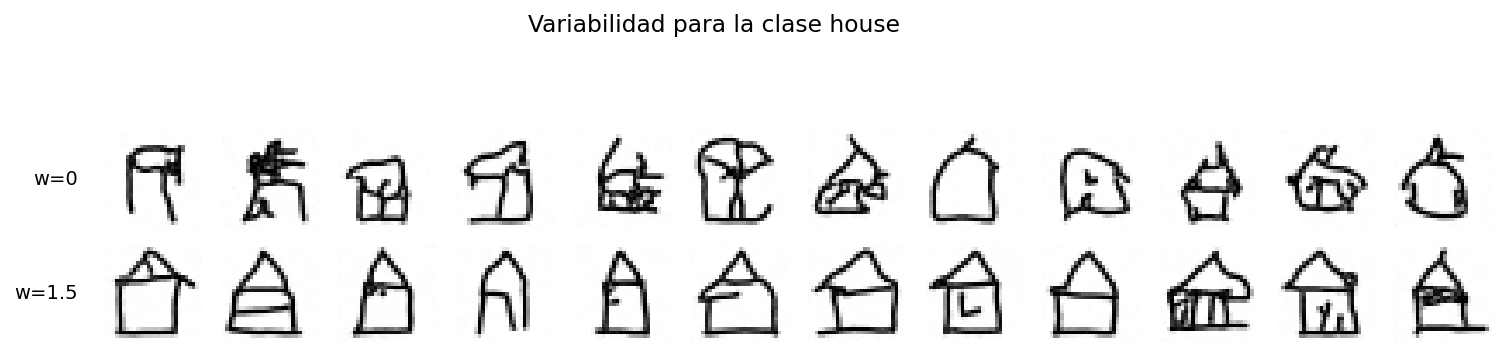

In [12]:
target_class = 0
target_name = class_names[target_class]
n_samples = 12
labels = torch.full((n_samples,), target_class, device=DEVICE, dtype=torch.long)

samples_w0, _ = sample_ddpm_cfg(model, labels, guidance_weight=0.0, save_steps=[0])
samples_w15, _ = sample_ddpm_cfg(model, labels, guidance_weight=1.5, save_steps=[0])

fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 0.95, 2.5))
for j in range(n_samples):
    axes[0, j].imshow(to_image_range(samples_w0[j, 0]), vmin=0, vmax=1)
    axes[1, j].imshow(to_image_range(samples_w15[j, 0]), vmin=0, vmax=1)
    axes[0, j].axis("off")
    axes[1, j].axis("off")
axes[0, 0].text(-0.28, 0.5, "w=0", transform=axes[0, 0].transAxes, ha="right", va="center")
axes[1, 0].text(-0.28, 0.5, "w=1.5", transform=axes[1, 0].transAxes, ha="right", va="center")
fig.suptitle(f"Variabilidad para la clase {target_name}", y=1.04)
fig.tight_layout(rect=[0.05, 0.0, 1.0, 0.94])

## Lectura crítica

Classifier-free guidance suele mejorar la adhesión a la condición, pero no es una garantía de calidad universal. Cuando $w$ crece, el muestreo se aleja de la predicción condicional ordinaria y extrapola una dirección semántica. Esa extrapolación puede reforzar rasgos de clase, pero también puede reducir diversidad o introducir artefactos.

Esta tensión es fundamental. Guidance es un mecanismo de control durante muestreo, no una corrección mágica del entrenamiento. Si la red no aprendió bien el modo condicional o el modo nulo, la diferencia entre ambas predicciones será pobre. Por eso el entrenamiento con condición ausente debe verse como parte estructural del método, no como un detalle de implementación.

## Síntesis

Classifier-free guidance entrena una única red de predicción de ruido sobre condiciones reales y una condición nula. Durante el muestreo, la red se evalúa en ambos modos y se construye una predicción guiada:

$$
\epsilon_{\mathrm{cfg}}
=
\epsilon_\theta(x_t,t,y)
+
w\left[
\epsilon_\theta(x_t,t,y)
-
\epsilon_\theta(x_t,t,\varnothing)
\right].
$$

El proceso directo no cambia. La arquitectura apenas se modifica para incluir un token adicional. El control aparece en la cadena inversa: $w$ regula cuánto se amplifica la diferencia entre la predicción condicional y la no condicional.

## Preguntas de discusión

1. ¿Por qué la condición nula no debe interpretarse como una nueva clase del dataset?
2. ¿Qué aprende la red cuando recibe $\varnothing$ durante entrenamiento?
3. ¿Por qué classifier-free guidance requiere dos evaluaciones de la misma red durante cada paso de muestreo?
4. ¿Qué significa geométricamente la diferencia $\epsilon_{\mathrm{cond}}-\epsilon_{\mathrm{null}}$?
5. ¿Por qué valores muy altos de $w$ pueden deteriorar algunas muestras?

## Continuidad

Hasta este punto hemos trabajado con la formulación DDPM discreta: proceso directo, objetivo de denoising, muestreo inverso, modelos condicionales y guidance. El siguiente bloque conceptual puede avanzar hacia score matching, donde la predicción de ruido se conecta con campos de dirección asociados a la densidad de datos.